# Clasificando gestos musculares

## Cuatro gestos de la mano:
1. Piedra - 0

2. Tijera - 1

3. Papel - 2

4. Ok - 3


Nuestro objetivo es crear un clasificador que distinga correctamente entre estos 4 gestos, gestionando problemas como robustez al ruido y capacidad de generalización con múltiples sujetos.

In [1]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import math

## Cargando datos

In [4]:
# 4 csvs (1 por clase) -> unirlos en 1

df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)


# última col -> label (65)
df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

In [19]:
df_0

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,64
0,26.0,4.0,5.0,8.0,-1.0,-13.0,-109.0,-66.0,-9.0,2.0,...,-28.0,61.0,4.0,8.0,5.0,4.0,-7.0,-59.0,16.0,0
1,-47.0,-6.0,-5.0,-7.0,13.0,-1.0,35.0,-10.0,10.0,-4.0,...,-25.0,47.0,6.0,6.0,5.0,13.0,21.0,111.0,15.0,0
2,-19.0,-8.0,-8.0,-8.0,-21.0,-6.0,-79.0,12.0,0.0,5.0,...,-83.0,7.0,7.0,1.0,-8.0,7.0,21.0,114.0,48.0,0
3,2.0,3.0,0.0,2.0,0.0,22.0,106.0,-14.0,-16.0,-2.0,...,-38.0,-11.0,4.0,7.0,11.0,33.0,39.0,119.0,43.0,0
4,6.0,0.0,0.0,-2.0,-14.0,10.0,-51.0,5.0,7.0,0.0,...,38.0,-35.0,-8.0,2.0,6.0,-13.0,-24.0,-112.0,-69.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2905,-12.0,0.0,0.0,-7.0,-4.0,-3.0,-1.0,-5.0,4.0,-1.0,...,12.0,-3.0,0.0,2.0,-1.0,-1.0,4.0,-30.0,-20.0,0
2906,-9.0,-1.0,-2.0,1.0,-13.0,-14.0,-59.0,-4.0,-9.0,0.0,...,20.0,-4.0,0.0,0.0,0.0,-21.0,-10.0,-14.0,-29.0,0
2907,3.0,-2.0,-2.0,4.0,18.0,-5.0,-31.0,7.0,-3.0,-3.0,...,34.0,-7.0,4.0,4.0,2.0,1.0,4.0,-55.0,-4.0,0
2908,-2.0,-2.0,-2.0,1.0,-3.0,-17.0,-33.0,-13.0,3.0,2.0,...,-4.0,0.0,3.0,0.0,5.0,9.0,8.0,-13.0,11.0,0


In [5]:
np.array([np.mean(df_0.iloc[:, 0][i:i + 50]) for i in range((df_0.shape[0] // 50))])

array([ 0.9 , -0.28,  0.34,  0.72,  0.46,  0.66,  0.24,  0.4 , -0.16,
        0.38,  1.68,  1.36,  1.58,  0.8 ,  1.3 ,  0.9 ,  1.3 ,  1.76,
        3.3 ,  3.9 ,  3.26,  1.48,  1.28,  1.3 ,  1.66,  1.98,  1.84,
        1.92,  1.64,  2.8 ,  1.5 ,  1.24,  0.58, -0.88, -0.28, -0.64,
       -0.06,  0.72, -0.28,  0.38,  0.94,  2.3 ,  1.44,  2.22,  1.08,
        1.4 ,  1.16,  1.12,  2.52,  1.8 ,  1.7 ,  1.96,  2.42,  2.86,
        2.16,  1.64,  1.78,  1.4 ])

In [6]:
np.arange(0, df_0.shape[0], 50)

array([   0,   50,  100,  150,  200,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050,
       1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600,
       1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000, 2050, 2100, 2150,
       2200, 2250, 2300, 2350, 2400, 2450, 2500, 2550, 2600, 2650, 2700,
       2750, 2800, 2850, 2900])

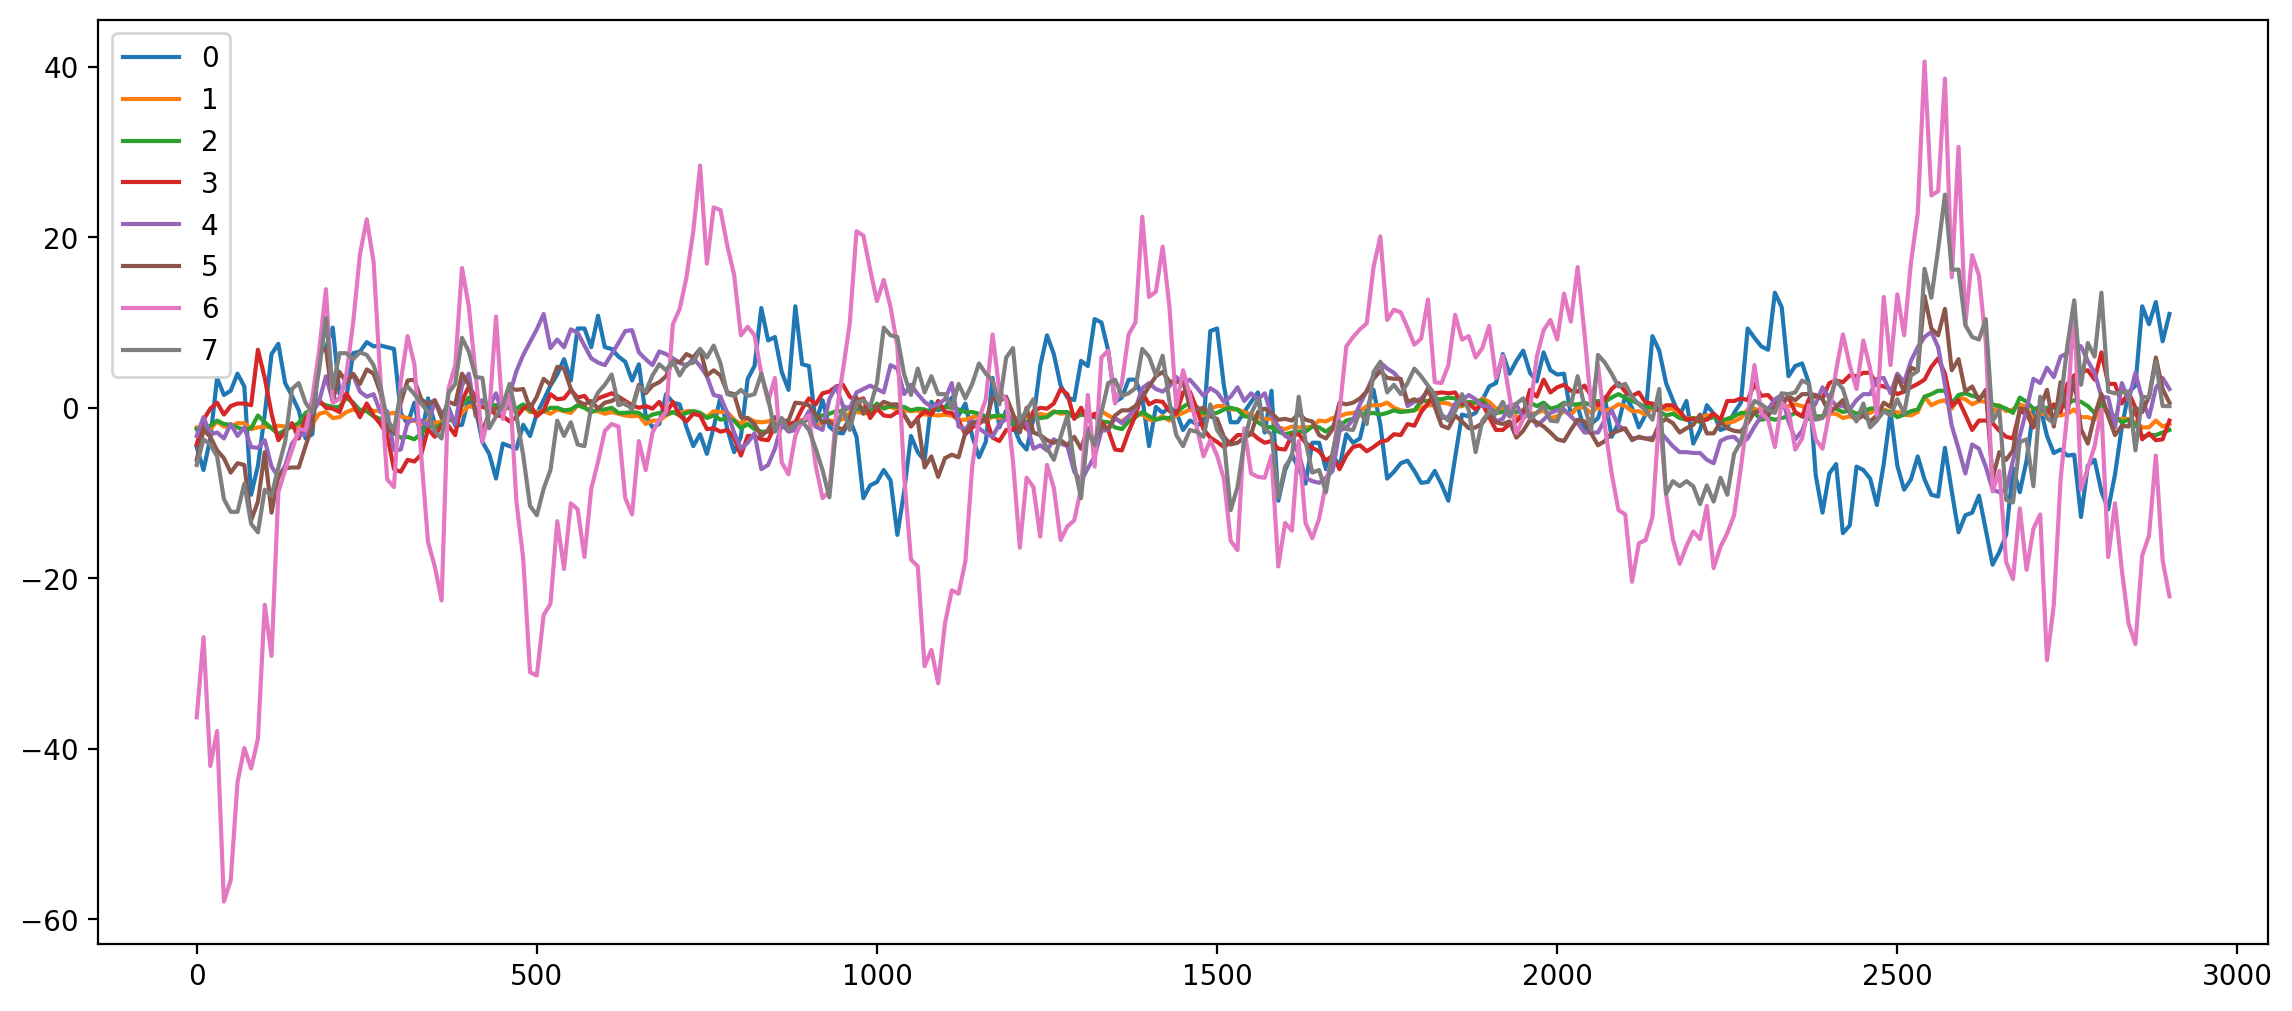

In [7]:
plt.figure(figsize=(14, 6), dpi=200)
window = 10
for i in range(8):
    # plt.plot(df_0.iloc[:, i])
    a = np.array([np.mean(df_0.iloc[:, i][j:j + window]) for j in range(math.floor(df_0.shape[0] / window))])
    plt.plot(np.arange(0, df_0.shape[0], window), a, label=f"{i}")

plt.legend()
plt.show()

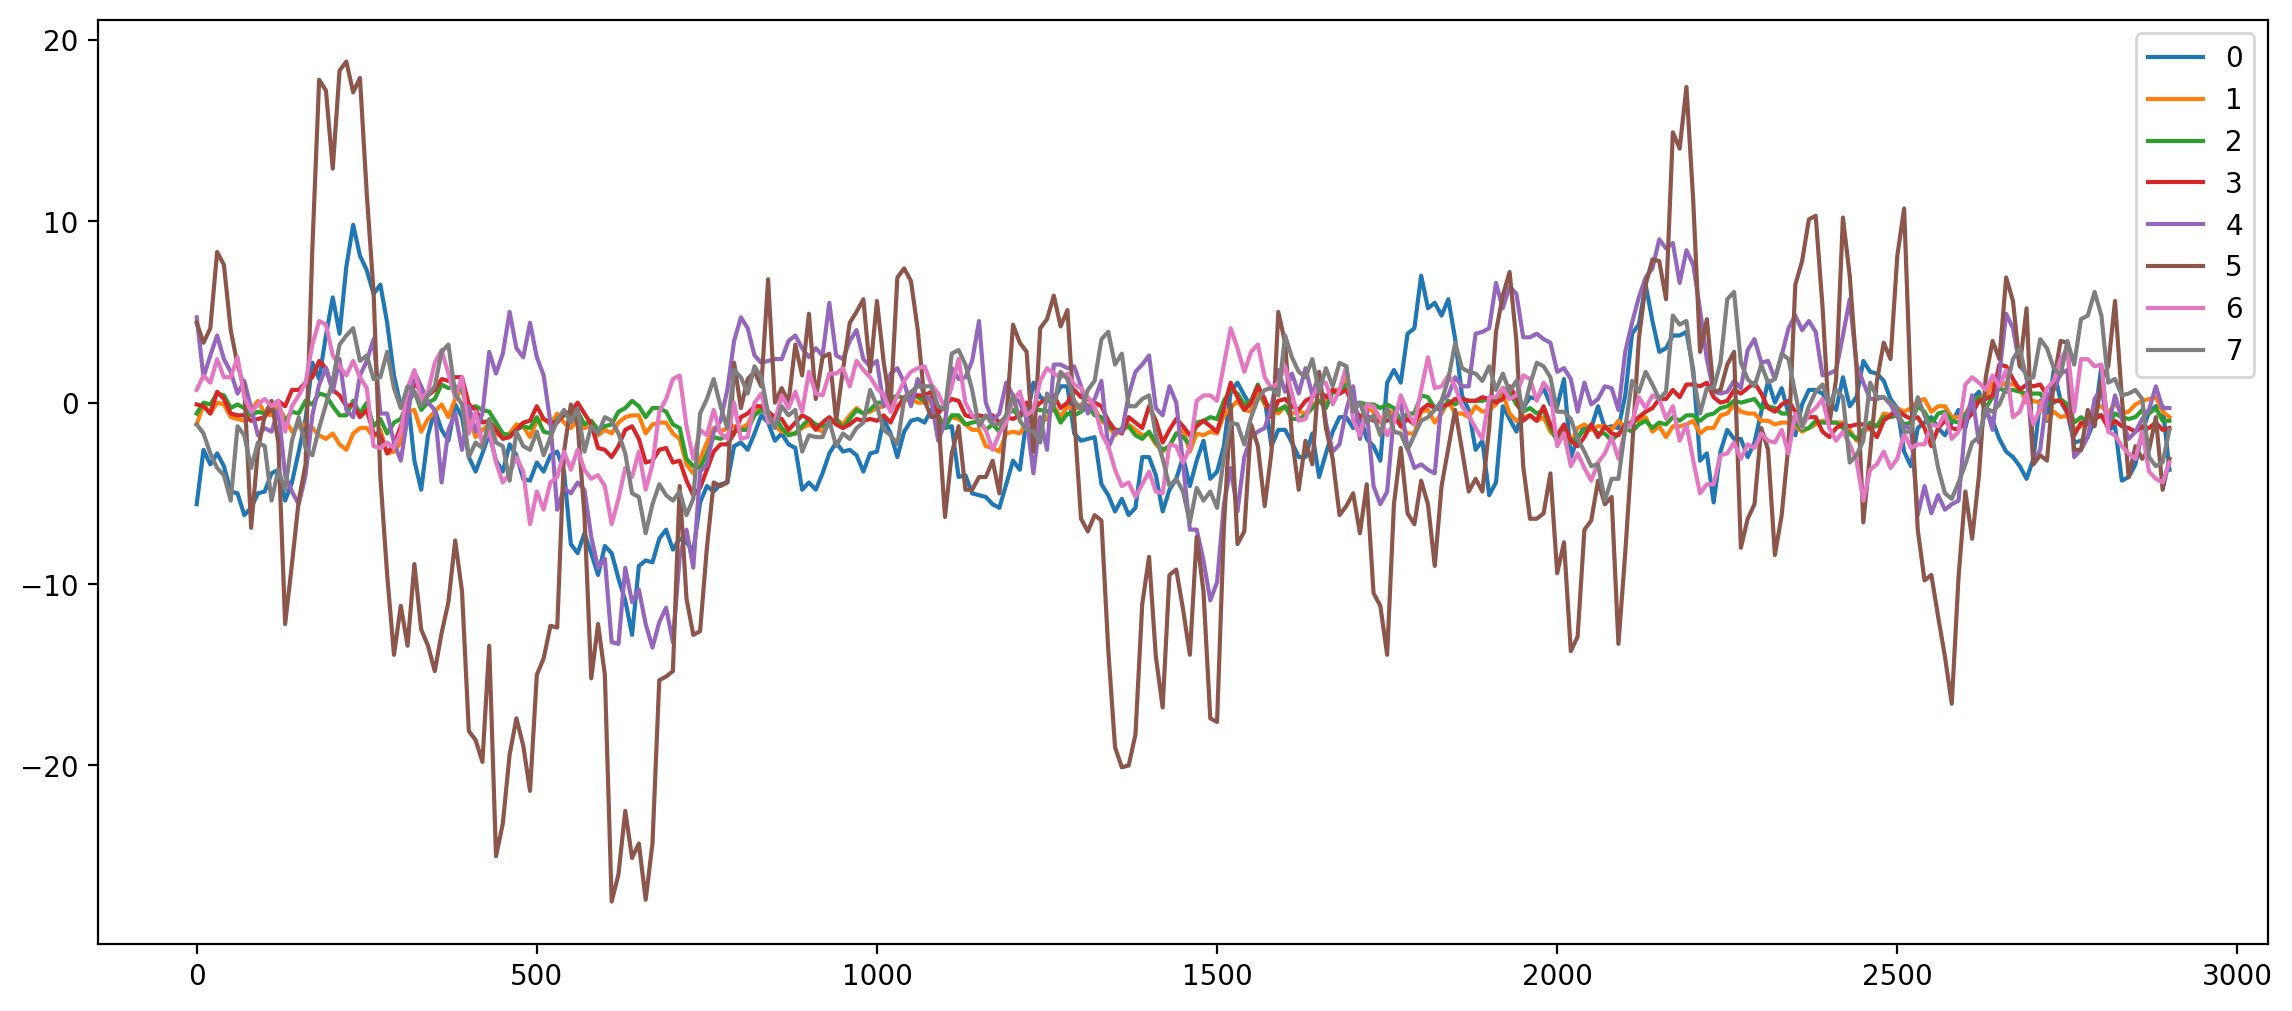

In [44]:
plt.figure(figsize=(14, 6), dpi=200)
window = 10
for i in range(8):
    # plt.plot(df_0.iloc[:, i])
    a = np.array([np.mean(df_3.iloc[:, i][j:j + window]) for j in range(math.floor(df_1.shape[0] / window) + 1)])
    plt.plot(np.arange(0, df_1.shape[0], window), a, label=f"{i}")

plt.legend()
plt.show()

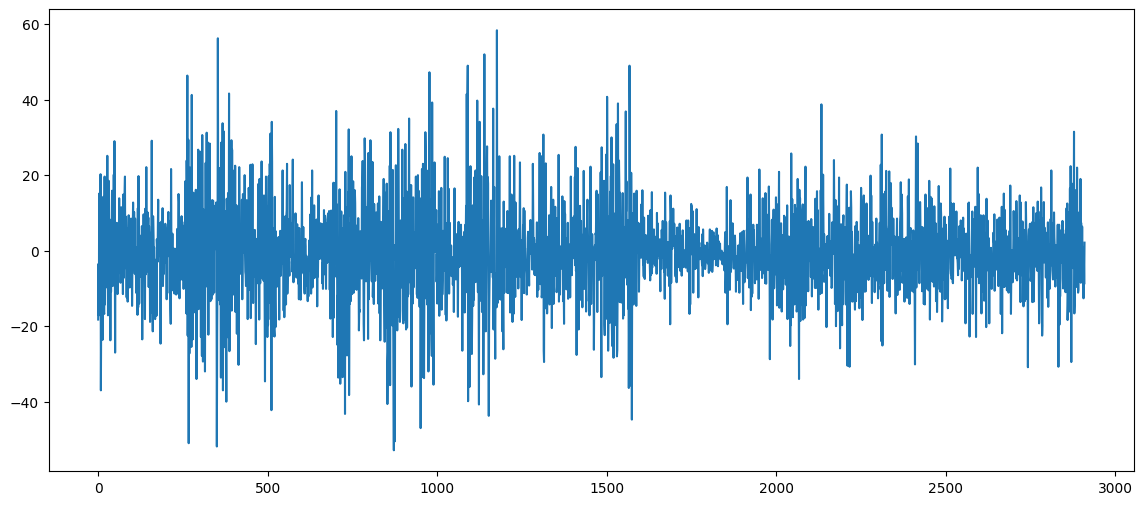

In [41]:
plt.figure(figsize=(14, 6))
plt.plot(range(2910),df_0.to_numpy()[:,:8].mean(axis=1))

In [22]:
np.mean(df_0.to_numpy()[:, :8],axis=1)

array([-18.25 ,  -3.5  , -17.125, ...,  -1.   ,  -8.875,   2.125],
      shape=(2910,))

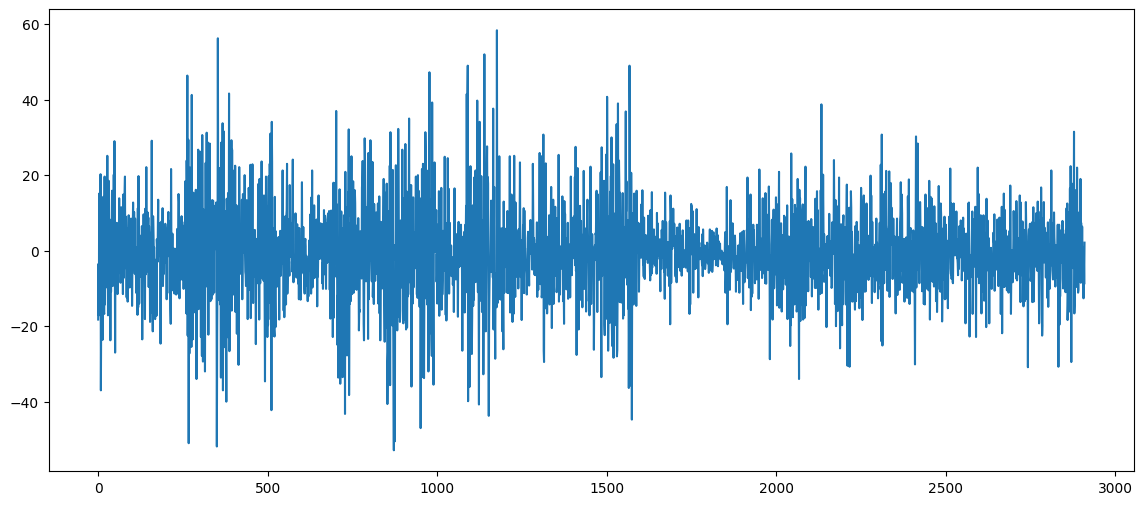

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(np.mean(df_0.to_numpy()[:, :8], axis=1))
plt.show()

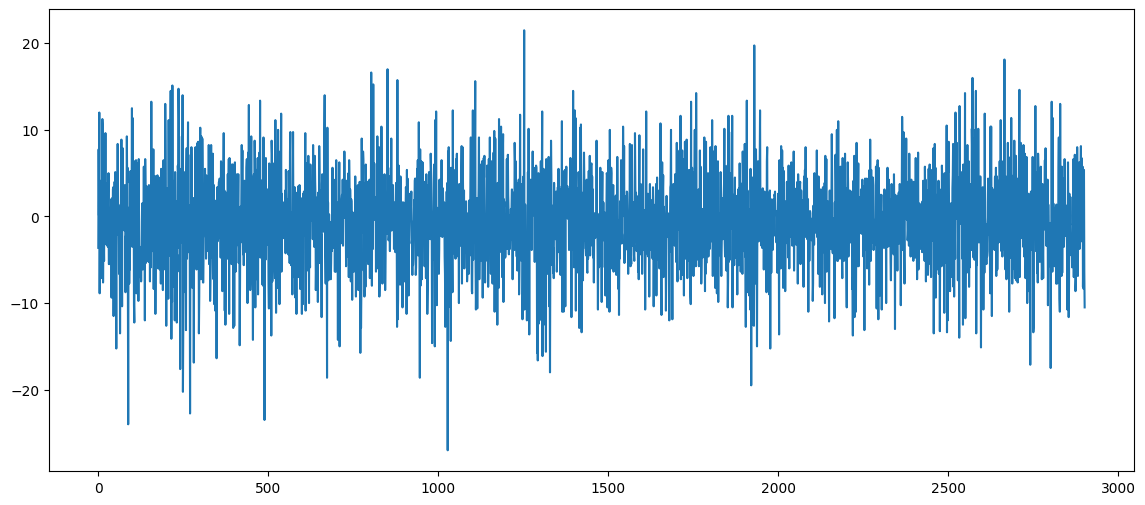

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(np.mean(df_1.to_numpy()[:, :8], axis=1))
plt.show()

### Balance de clases

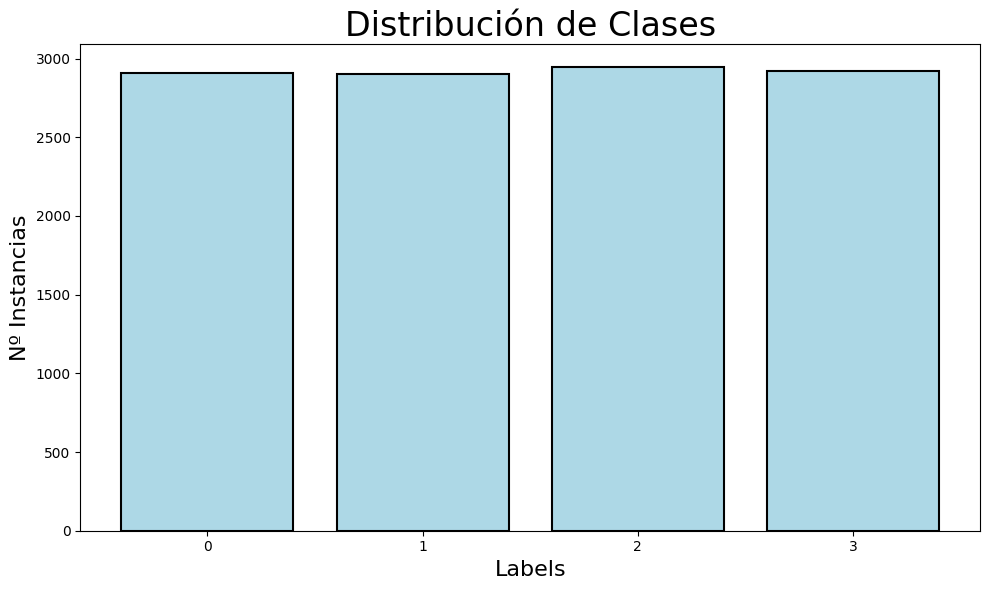

In [11]:
plt.figure(figsize=(10, 6))

instancias_por_clase = {"0" : len(df_0), # label : n_instancias
                        "1" : len(df_1),
                        "2" : len(df_2),
                        "3" : len(df_3)}

# bar plot
labels = instancias_por_clase.keys()
n_instancias = instancias_por_clase.values()
plt.bar(labels, n_instancias, edgecolor="black", lw=1.5, color="lightblue")
plt.title("Distribución de Clases", fontsize=24)
plt.xlabel("Labels", fontsize=16)
plt.ylabel("Nº Instancias", fontsize=16)
plt.tight_layout()
plt.show()

## Visualización

In [12]:
# separar características y labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    random_state=42,
    )
X_umap = reducer.fit_transform(X_scaled)

/home/jose21172/Escritorio/tercero_universidad/aprendizaje_avanzado/Proyecto-AA-EMG_sensors/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


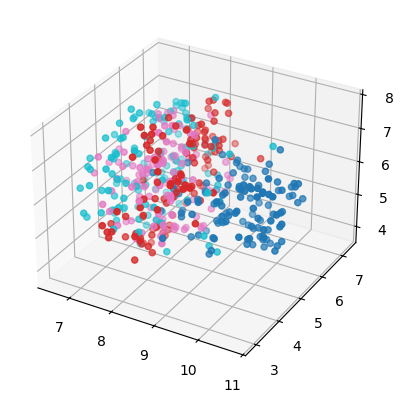

In [13]:
mask = np.random.choice(np.arange(len(X_umap)), size=500, replace=False)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_umap[mask, 0], X_umap[mask, 1], X_umap[mask, 2], c=y[mask], cmap="tab10")
plt.show()